# Exploratory Data Analysis

## CareBridge — Diabetes Readmission Risk and Cardiometabolic Comorbidity

**Team Lead:** Antoine Ward
**Program:** B.S. Data Science Capstone

| | |
|---|---|
| Clinical source | Diabetes 130-US Hospitals, 101,766 encounters |
| Survey source | CDC BRFSS 2015, 253,680 respondents |
| Analytic cohort | 70,436 patients, first encounter each |
| Outcome | 30-day unplanned readmission, 8.94% prevalence |

---

## 1. Purpose and Scope

This notebook documents the exploratory analysis of both project data sources. Its purpose is to
characterize the distribution of every variable used in the analysis, identify the relationships
that motivate the modeling specification, and surface the data properties that constrain which
methods are appropriate.

Every statistic here is **descriptive**. No model is fitted and no inferential test is reported;
those follow in the statistical analysis. Analysis proceeds in four stages:

1. Univariate distributions
2. Bivariate relationships with the readmission outcome
3. Correlation structure among predictors
4. Population-level survey outcomes

In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from carebridge.config import RAW
from carebridge.features.build import build

%matplotlib inline

NAVY, MID, LIGHT = "#1F3864", "#8FA5C7", "#DCE3EF"
ACCENT, SLATE = "#A6462E", "#44546A"

plt.rcParams.update({
    "figure.dpi": 110,
    "font.size": 9,
    "axes.edgecolor": SLATE, "axes.labelcolor": SLATE,
    "xtick.color": SLATE, "ytick.color": SLATE,
    "axes.titlesize": 10, "axes.titleweight": "bold", "axes.titlecolor": NAVY,
    "figure.facecolor": "white",
})
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 40)


def clean(ax, grid_axis="y"):
    """Gridlines behind the data, no box around the plot."""
    ax.grid(axis=grid_axis, color="#DDDDDD", linewidth=0.7)
    ax.set_axisbelow(True)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)

In [2]:
df = build()
BASE = 100 * df["readmitted_30d"].mean()

print(f"cohort:    {df.shape[0]:,} patients, {df.shape[1]} columns")
print(f"outcome:   {BASE:.2f}% 30-day readmission")
print(f"patients:  {df['patient_nbr'].nunique():,} distinct")

cohort:    70,436 patients, 66 columns
outcome:   8.94% 30-day readmission
patients:  70,436 distinct


---

## 2. Data Quality Context

Three cleaning decisions determine the composition of the analytic cohort. They are documented in
full in the accompanying Data Quality Assessment and summarized here because they affect the
interpretation of every figure that follows.

- **Leakage exclusion.** Encounters where the patient expired (discharge disposition 11, 19, 20)
  are excluded, verified empirically at a 0.000% observed readmission rate across 1,652
  encounters. Hospice dispositions (13, 14) are **retained**, contrary to common practice, because
  those patients are alive and readmit at 4.76% and 6.45%.
- **Repeat patients.** 100,111 cleaned encounters come from 70,436 distinct patients. The primary
  cohort retains the first encounter per patient.
- **Medication adjustment.** The source `change` column flags *continued* medication rather than
  therapeutic adjustment. An adjustment indicator is derived directly from the individual drug
  columns.

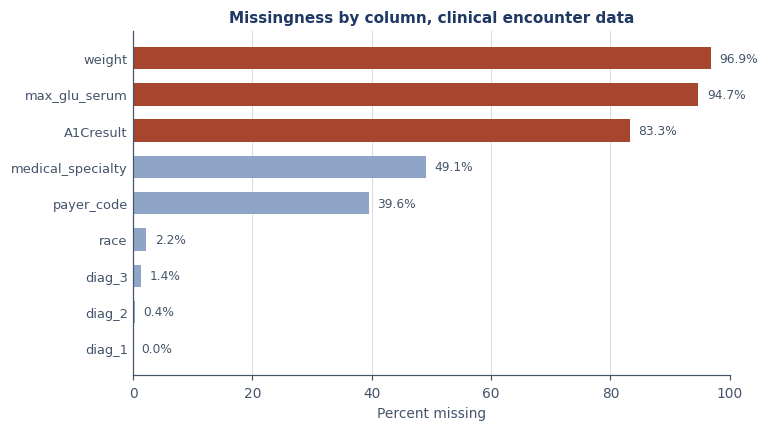

In [3]:
# Missingness in the raw clinical file. '?' is the sentinel, not an empty field --
# left unconverted it forms its own category and inflates completeness counts.
raw = pd.read_csv(RAW / "diabetes_encounters" / "diabetic_data.csv", dtype=str)
miss = ((raw == "?") | raw.isna()).mean().mul(100).sort_values(ascending=False)
miss = miss[miss > 0]

fig, ax = plt.subplots(figsize=(7.0, 0.34 * len(miss) + 1.0))
ax.barh(range(len(miss)), miss.values, height=0.62,
        color=[ACCENT if v > 50 else MID for v in miss.values])
ax.set_yticks(range(len(miss)), miss.index, fontsize=8.5)
ax.invert_yaxis()
ax.set_xlim(0, 100)
ax.set_xlabel("Percent missing")
ax.set_title("Missingness by column, clinical encounter data")
for i, v in enumerate(miss.values):
    ax.text(v + 1.4, i, f"{v:.1f}%", va="center", fontsize=8, color=SLATE)
clean(ax, "x"); ax.tick_params(axis="y", length=0)
plt.show()

Weight is missing in roughly 97% of records and is **dropped rather than imputed** — at that rate
any imputation would be a model output presented as observed data. Medical specialty (49.1%) and
payer code (39.5%) are retained with missingness encoded as an explicit category, since which
fields go unrecorded reflects real differences in documentation and may itself carry signal.

In [4]:
# Empirical validation of the exclusion rule. A code meaning "expired" makes a
# testable prediction: the readmission rate must be exactly zero.
EXPIRED, HOSPICE = {11, 19, 20}, {13, 14}
raw["disp"] = pd.to_numeric(raw["discharge_disposition_id"], errors="coerce")

audit = (raw[raw.disp.isin(EXPIRED | HOSPICE)]
         .groupby("disp")
         .agg(n=("readmitted", "size"),
              pct_readmit_30d=("readmitted", lambda s: 100 * (s == "<30").mean()))
         .round(3))
audit["treatment"] = np.where(audit.index.isin(EXPIRED), "EXCLUDE (expired)",
                              "RETAIN (hospice)")
print(f"encounter-level baseline: {100 * (raw.readmitted == '<30').mean():.2f}%\n")
audit

encounter-level baseline: 11.16%



,n,pct_readmit_30d,treatment
disp,,,
11,1642,0.000,EXCLUDE (expired)
13,399,4.762,RETAIN (hospice)
14,372,6.452,RETAIN (hospice)
19,8,0.000,EXCLUDE (expired)
20,2,0.000,EXCLUDE (expired)


Codes 11, 19, and 20 return **exactly 0.000%** across 1,652 encounters. Readmission is
structurally impossible for these patients, so retaining them in the negative class constitutes
target leakage.

Codes 13 and 14 return 4.76% and 6.45% against an 11.16% encounter-level baseline. These patients
are alive and are readmitted at roughly half the base rate. Excluding them — as the conventional
six-code rule does — would discard 771 encounters containing genuine readmission events and bias
the cohort toward a healthier population.

The naming is the likely source of the conflation: codes 19 and 20 contain the word *hospice* but
describe patients who **expired while in hospice**.

---

## 3. Univariate Distributions

Eight numeric features describe each encounter. Their distributions determine whether linear model
specifications are appropriate and which transformations are required.

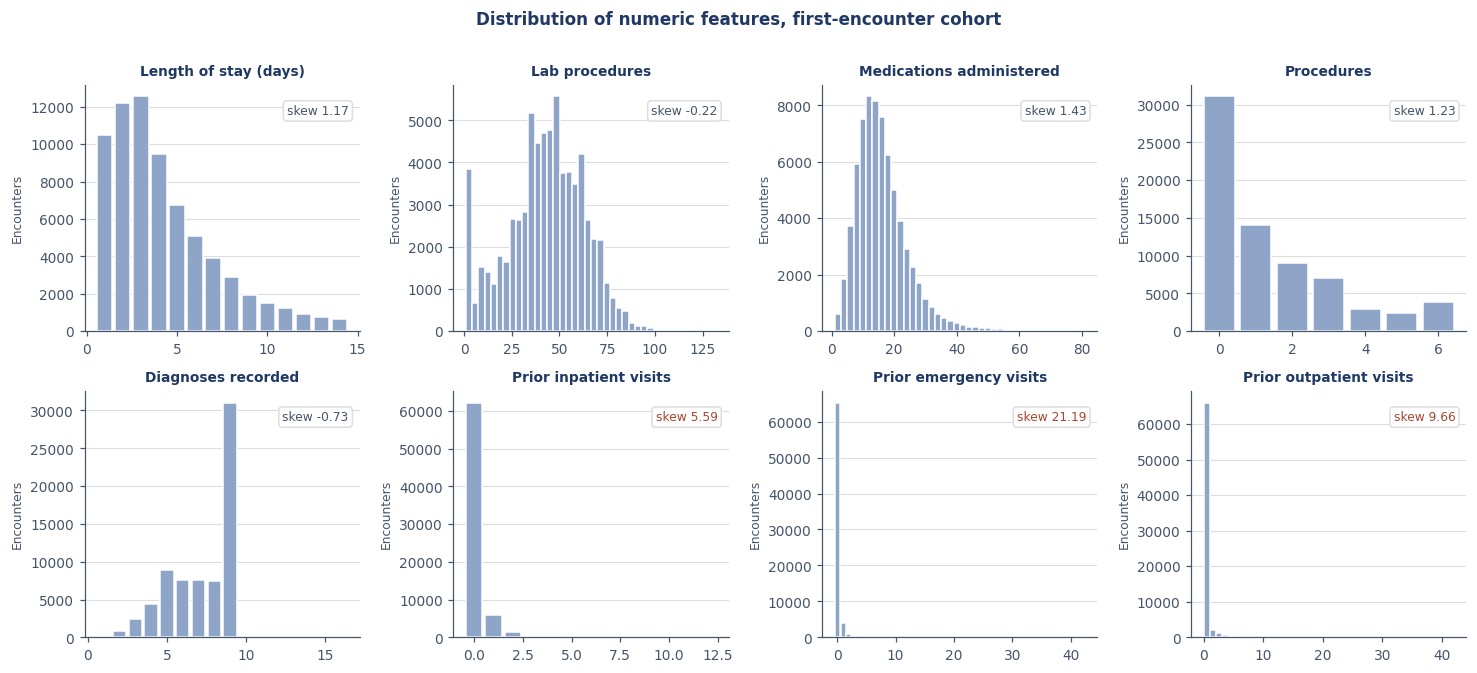

In [5]:
NUMERIC = [
    ("time_in_hospital", "Length of stay (days)"),
    ("num_lab_procedures", "Lab procedures"),
    ("num_medications", "Medications administered"),
    ("num_procedures", "Procedures"),
    ("number_diagnoses", "Diagnoses recorded"),
    ("number_inpatient", "Prior inpatient visits"),
    ("number_emergency", "Prior emergency visits"),
    ("number_outpatient", "Prior outpatient visits"),
]

fig, axes = plt.subplots(2, 4, figsize=(13.5, 6.0))
for ax, (col, label) in zip(axes.ravel(), NUMERIC):
    x = df[col].dropna()
    skew = stats.skew(x)

    # discrete variables with few levels get exact counts, not arbitrary bins
    if x.nunique() <= 25:
        c = x.value_counts().sort_index()
        ax.bar(c.index, c.values, color=MID, edgecolor="white", width=0.85)
    else:
        ax.hist(x, bins=40, color=MID, edgecolor="white")

    ax.set_title(label, fontsize=9)
    ax.set_ylabel("Encounters", fontsize=8)
    clean(ax)
    ax.text(0.96, 0.92, f"skew {skew:.2f}", transform=ax.transAxes,
            ha="right", va="top", fontsize=8,
            color=ACCENT if abs(skew) > 2 else SLATE,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="#DDD"))

fig.suptitle("Distribution of numeric features, first-encounter cohort",
             fontsize=11, fontweight="bold", color=NAVY, y=1.01)
plt.tight_layout(); plt.show()

In [6]:
rows = []
for col, label in NUMERIC:
    x = df[col].dropna()
    q1, q3 = x.quantile([0.25, 0.75]); iqr = q3 - q1
    rows.append({
        "variable": label, "mean": x.mean(), "sd": x.std(ddof=1),
        "median": x.median(), "max": x.max(),
        "skewness": stats.skew(x), "kurtosis": stats.kurtosis(x),
        "pct_zero": 100 * (x == 0).mean(),
        "outliers_1_5_iqr": int(((x < q1 - 1.5*iqr) | (x > q3 + 1.5*iqr)).sum()),
    })
summary = pd.DataFrame(rows).round(2)
summary

,variable,mean,sd,median,max,skewness,kurtosis,pct_zero,outliers_1_5_iqr
0,Length of stay (days),4.28,2.94,3.0,14,1.17,0.99,0.00,1422
1,Lab procedures,42.92,19.90,44.0,132,-0.22,-0.30,0.00,99
2,Medications administered,15.67,8.28,14.0,81,1.43,3.85,0.00,1873
3,Procedures,1.42,1.75,1.0,6,1.23,0.57,44.12,3851
4,Diagnoses recorded,7.23,2.00,8.0,16,-0.73,-0.37,0.00,235
5,Prior inpatient visits,0.18,0.60,0.0,12,5.59,47.35,88.27,8265
6,Prior emergency visits,0.10,0.51,0.0,42,21.19,1207.94,92.71,5132
7,Prior outpatient visits,0.28,1.06,0.0,42,9.66,183.57,86.95,9189


### 3.1 Zero-inflation in the prior-utilization variables

The three prior-utilization counts are not merely right-skewed. They are **predominantly zero with
rare extreme values**, producing excess kurtosis far outside the range typical of skewed continuous
data.

| Variable | % zero | Skewness | Excess kurtosis | Max |
|---|---|---|---|---|
| Prior emergency visits | 92.71% | 21.19 | **1,207.94** | 42 |
| Prior outpatient visits | 86.95% | 9.66 | 183.57 | 42 |
| Prior inpatient visits | 88.27% | 5.59 | 47.35 | 12 |

A logarithmic transformation is the conventional remedy for right skew, but it does not address
this pattern: `log(1 + 0) = 0`, so the spike at zero survives unchanged and only the small non-zero
tail is rescaled. **Binary indicators were therefore derived alongside the log transforms**, and
section 4.1 shows the encoding choice materially changes what the data appear to say.

### 3.2 Features requiring no transformation

Two features are *left*-skewed rather than right-skewed. Lab procedures (skewness −0.22, excess
kurtosis −0.30) is approximately symmetric, and diagnoses recorded (−0.73) is mildly left-skewed.
Describing the feature set as uniformly right-skewed would be inaccurate.

### 3.3 Outlier detection does not transfer across variable types

Tukey's 1.5-IQR rule flags 3,851 records on the procedures variable, which takes only seven
distinct values from 0 to 6. With Q1 = 0 and Q3 = 2 the upper fence falls at 5, so **every patient
receiving five or six procedures is classified as an outlier**. That is the rule applied outside
its intended domain, not a genuine anomaly.

Winsorization is therefore specified per variable rather than as a blanket policy. It suits
medications administered, which has a real continuous tail reaching 81 against a median of 14. It
does not suit low-cardinality discrete counts.

---

## 4. Relationships With the Readmission Outcome

The cohort readmission rate is 8.94%. Each feature is examined against that baseline to establish
which carry univariate signal before any model is fitted. Binomial confidence intervals are shown
throughout, because bin sizes differ substantially and precision varies with them.

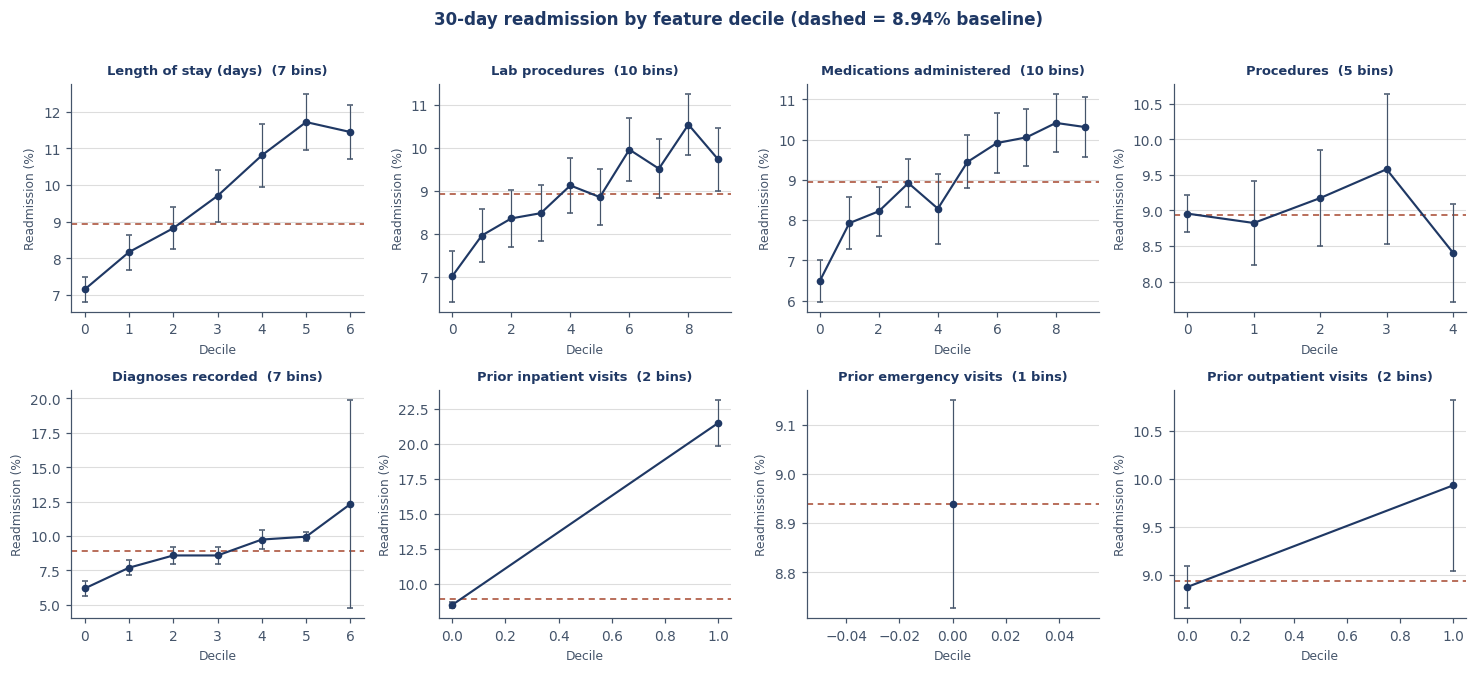

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(13.5, 6.0))
for ax, (col, label) in zip(axes.ravel(), NUMERIC):
    # duplicates="drop" is required, not defensive: when most values are zero,
    # multiple decile boundaries land on the same value and qcut would raise.
    q = pd.qcut(df[col], 10, labels=False, duplicates="drop")
    g = df.groupby(q, observed=True)["readmitted_30d"].agg(["mean", "size"])
    pct = 100 * g["mean"]
    se = 100 * np.sqrt(g["mean"] * (1 - g["mean"]) / g["size"])

    ax.errorbar(range(len(pct)), pct, yerr=1.96 * se, marker="o", color=NAVY,
                lw=1.4, ms=4, capsize=2, ecolor=SLATE, elinewidth=0.8)
    ax.axhline(BASE, color=ACCENT, lw=1.0, ls=(0, (4, 3)), zorder=1)
    ax.set_title(f"{label}  ({len(pct)} bins)", fontsize=8.5)
    ax.set_xlabel("Decile", fontsize=8)
    ax.set_ylabel("Readmission (%)", fontsize=8)
    clean(ax)

fig.suptitle(f"30-day readmission by feature decile (dashed = {BASE:.2f}% baseline)",
             fontsize=11, fontweight="bold", color=NAVY, y=1.01)
plt.tight_layout(); plt.show()

### 4.1 The encoding determines the apparent signal

Decile analysis requires ten distinct quantile boundaries. For variables that are predominantly
zero those boundaries collapse onto the same value and fewer bins form. **Prior emergency visits
produced a single bin**, making the decile spread exactly 0.00 and the variable appear entirely
uninformative.

Recomputing the same contrast as a binary comparison tells a different story.

In [8]:
rows = []

# deciles where the variable supports them
for col in ["number_diagnoses", "time_in_hospital", "num_medications",
            "num_lab_procedures", "num_procedures"]:
    q = pd.qcut(df[col], 10, labels=False, duplicates="drop")
    g = df.groupby(q, observed=True)["readmitted_30d"].mean() * 100
    rows.append({"feature": col, "encoding": f"{len(g)} bins",
                 "low_pct": round(g.iloc[0], 2), "high_pct": round(g.iloc[-1], 2),
                 "spread_pp": round(g.max() - g.min(), 2)})

# binary contrast for the zero-inflated ones
for col in ["number_inpatient", "number_emergency", "number_outpatient"]:
    g = df.groupby(df[col] > 0)["readmitted_30d"].mean() * 100
    rows.append({"feature": col, "encoding": "binary (any vs none)",
                 "low_pct": round(g.iloc[0], 2), "high_pct": round(g.iloc[1], 2),
                 "spread_pp": round(g.iloc[1] - g.iloc[0], 2)})

spread = pd.DataFrame(rows).sort_values("spread_pp", ascending=False).reset_index(drop=True)
spread

,feature,encoding,low_pct,high_pct,spread_pp
0,number_inpatient,binary (any vs none),8.09,15.34,7.25
1,number_diagnoses,7 bins,6.19,12.33,6.13
2,time_in_hospital,7 bins,7.15,11.45,4.57
3,num_medications,10 bins,6.49,10.31,3.93
4,num_lab_procedures,10 bins,7.02,9.74,3.52
5,number_emergency,binary (any vs none),8.70,11.98,3.28
6,number_outpatient,binary (any vs none),8.76,10.14,1.38
7,num_procedures,5 bins,8.96,8.41,1.17


Prior emergency visits shows a **3.28 percentage point contrast** under binary encoding — 11.98%
against 8.70% — ranking it above lab procedures. The variable was never uninformative; the encoding
was unable to represent it. This is reported as a methodological result, not merely a technical
detail.

**Prior inpatient visits is the strongest single predictor** under either encoding: a 7.25 point
binary contrast, rising to 12.98 across deciles where the upper bin captures more extreme
utilization. That the relationship continues to strengthen beyond the first prior visit indicates a
dose-response pattern rather than a simple threshold.

Procedures shows a weak **inverted** relationship — 8.41% in the highest bin against 8.96% in the
lowest. The direction is plausible: a patient who received procedures was treated for an
identifiable, correctable problem, whereas a patient managed medically may have presented with a
chronic decompensation liable to recur.

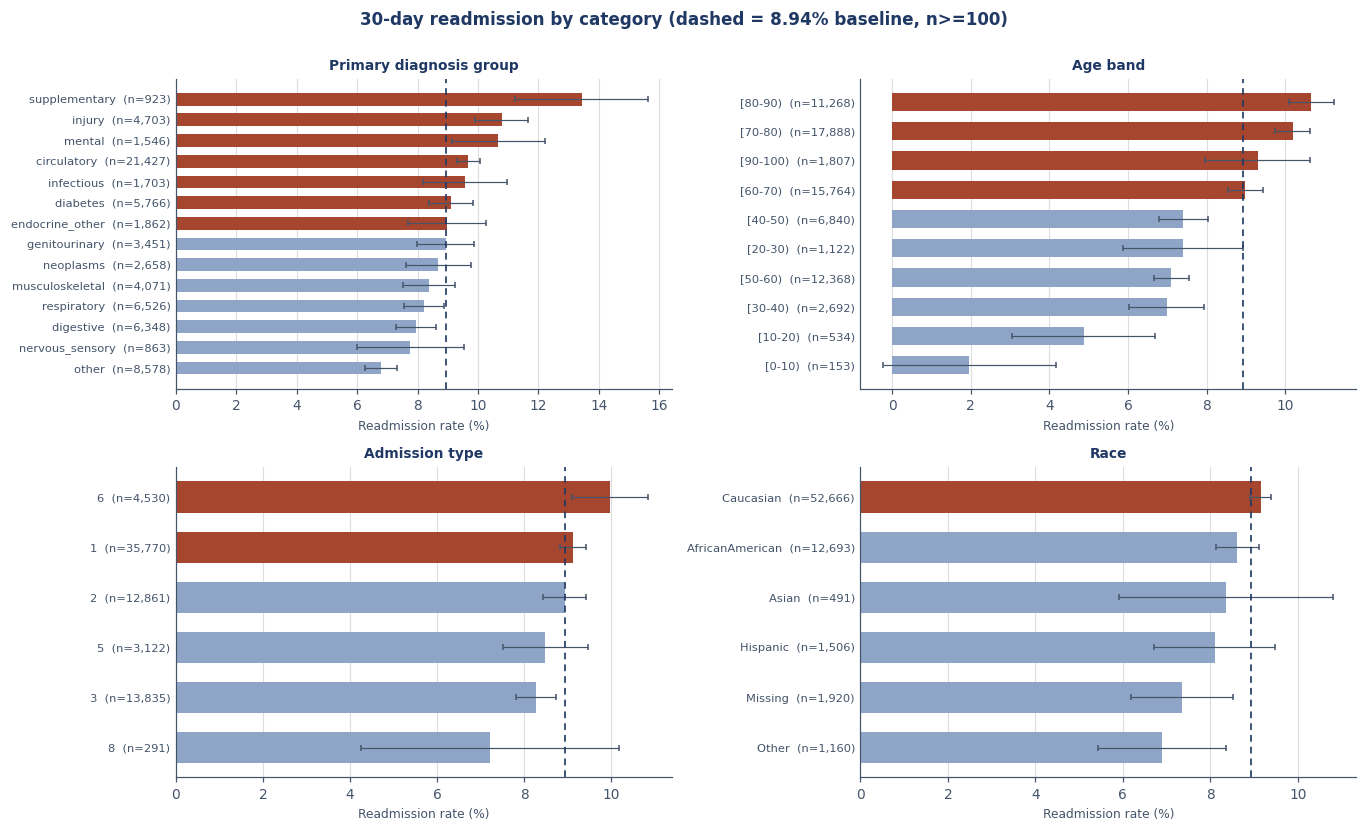

In [9]:
CATEGORICAL = [
    ("diag_1_group", "Primary diagnosis group"),
    ("age_band", "Age band"),
    ("admission_type_id", "Admission type"),
    ("race", "Race"),
]

fig, axes = plt.subplots(2, 2, figsize=(12.5, 7.5))
for ax, (col, label) in zip(axes.ravel(), CATEGORICAL):
    g = (df.groupby(col, observed=True)["readmitted_30d"]
           .agg(["mean", "size"]).query("size >= 100").sort_values("mean"))
    pct = 100 * g["mean"]
    se = 100 * np.sqrt(g["mean"] * (1 - g["mean"]) / g["size"])

    ax.barh(range(len(pct)), pct, height=0.62,
            color=[ACCENT if v > BASE else MID for v in pct],
            xerr=1.96 * se,
            error_kw=dict(ecolor=SLATE, elinewidth=0.8, capsize=2))
    ax.set_yticks(range(len(pct)),
                  [f"{i}  (n={n:,})" for i, n in zip(pct.index, g["size"])],
                  fontsize=7.5)
    ax.axvline(BASE, color=NAVY, lw=1.1, ls=(0, (4, 3)))
    ax.set_xlabel("Readmission rate (%)", fontsize=8)
    ax.set_title(label, fontsize=9)
    clean(ax, "x"); ax.tick_params(axis="y", length=0)

fig.suptitle(f"30-day readmission by category (dashed = {BASE:.2f}% baseline, n>=100)",
             fontsize=11, fontweight="bold", color=NAVY, y=1.00)
plt.tight_layout(); plt.show()

### 4.2 Categorical patterns

Primary diagnosis group shows the widest categorical variation. Supplementary classification codes,
which mark aftercare and complications of prior treatment, carry the highest readmission rate,
followed by injury and mental disorders. That ordering is clinically coherent — all three describe
populations with elevated care-transition risk.

Unadjusted rates across recorded race categories span **2.25 percentage points**, from 6.90% to
9.15%. These differences confound age, comorbidity burden, insurance status, and prior utilization,
and support no causal interpretation. Category sizes are also highly unequal, from 491 to 52,666
patients, so intervals for the smaller groups overlap most of the others.

The relevant question for the subsequent fairness audit is **not whether base rates differ** but
whether model sensitivity differs at a fixed operating threshold.

---

## 5. Correlation Structure

Three derived features — procedures, medications, and lab procedures per day — are computed by
dividing a count by length of stay, and length of stay is itself a predictor. This creates a
structural risk of collinearity that would destabilize coefficient estimates in a regression.

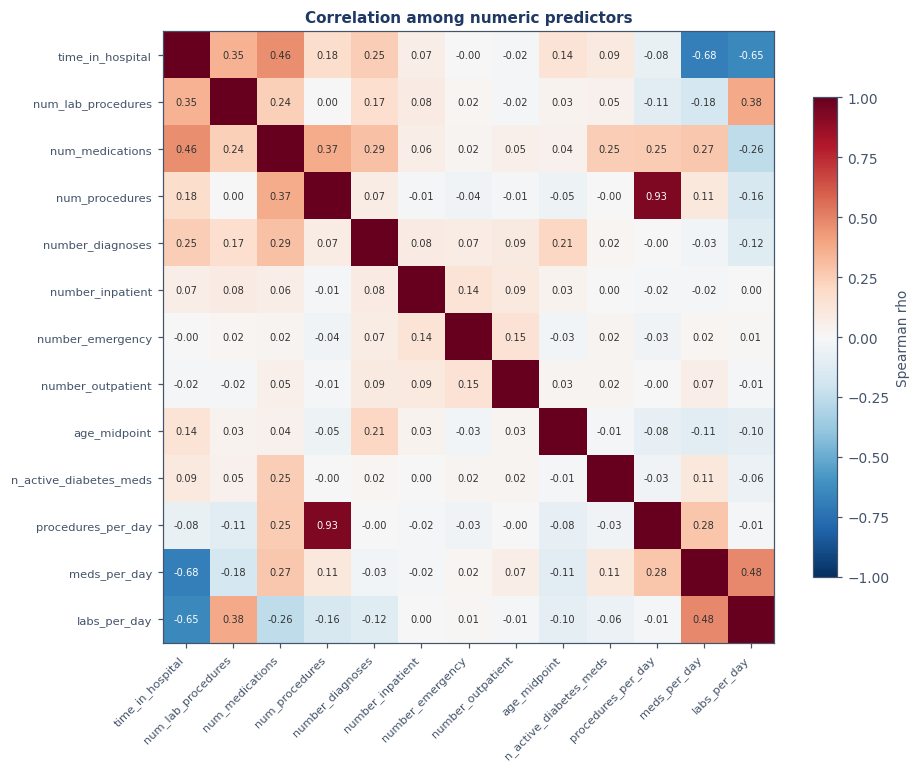

In [10]:
CORR_FEATURES = [
    "time_in_hospital", "num_lab_procedures", "num_medications",
    "num_procedures", "number_diagnoses",
    "number_inpatient", "number_emergency", "number_outpatient",
    "age_midpoint", "n_active_diabetes_meds",
    "procedures_per_day", "meds_per_day", "labs_per_day",
]

# Spearman, not Pearson: several features are heavily skewed counts, for which a
# linear correlation would be dominated by a handful of extreme values.
corr = df[CORR_FEATURES].corr(method="spearman")

fig, ax = plt.subplots(figsize=(8.6, 7.4))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
n = len(CORR_FEATURES)
ax.set_xticks(range(n), CORR_FEATURES, rotation=45, ha="right", fontsize=7.5)
ax.set_yticks(range(n), CORR_FEATURES, fontsize=7.5)
for i in range(n):
    for j in range(n):
        if i == j:
            continue
        v = corr.iloc[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=6.5,
                color="white" if abs(v) > 0.55 else "#333333")
fig.colorbar(im, ax=ax, shrink=0.7, label="Spearman rho")
ax.set_title("Correlation among numeric predictors", fontsize=10)
plt.tight_layout(); plt.show()

In [11]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

# The constant must be in the design matrix or VIF is computed as though the
# regression passes through the origin, inflating every value.
X = sm.add_constant(df[CORR_FEATURES].astype(float))
vif = pd.DataFrame(
    [{"feature": X.columns[i], "vif": variance_inflation_factor(X.values, i)}
     for i in range(X.shape[1])]
).query("feature != 'const'").sort_values("vif", ascending=False).reset_index(drop=True)
vif["flag"] = pd.cut(vif["vif"], [0, 5, 10, np.inf], labels=["ok", "elevated", "severe"])
vif.round(2)

,feature,vif,flag
0,meds_per_day,4.04,ok
1,labs_per_day,3.51,ok
2,procedures_per_day,3.44,ok
3,num_medications,3.35,ok
4,num_procedures,3.22,ok
5,time_in_hospital,3.10,ok
6,num_lab_procedures,2.48,ok
7,number_diagnoses,1.18,ok
8,age_midpoint,1.09,ok
9,n_active_diabetes_meds,1.08,ok


The maximum variance inflation factor is **4.04**, below the conventional threshold of 5. The rate
features and their underlying counts are mildly related but not redundant, because length of stay
is itself only weakly explained by the remaining predictors — medication count and medication
intensity measure distinguishable quantities.

All thirteen numeric predictors are therefore retained without selection on collinearity grounds.

The three prior-utilization variables show variance inflation near **1.0**, meaning they carry
information largely independent of the clinical and encounter features. Combined with the finding
that prior inpatient visits is the strongest univariate predictor, that is the most favorable
profile a predictor can have, and it suggests the relationship is unlikely to weaken substantially
under adjustment.

---

## 6. Population Survey Outcomes

The survey source supports the second research question: predictors of diabetes, stroke, and
cardiac disease at population level, and the degree to which those conditions co-occur.

All prevalences are **unweighted**. The public extract omits the complex survey weights, so
estimates describe the respondent sample rather than the United States adult population.

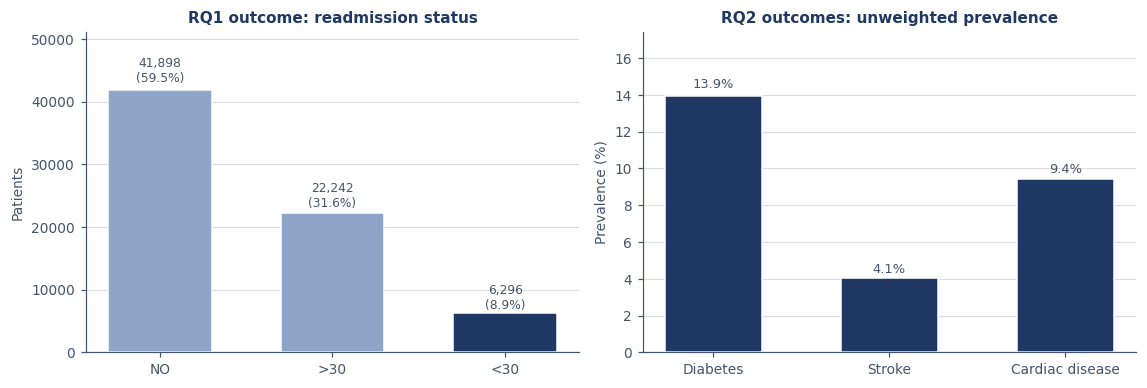

In [12]:
brfss = pd.read_csv(
    RAW / "brfss_indicators" / "diabetes_binary_health_indicators_BRFSS2015.csv")

OUTCOMES = {"Diabetes": "Diabetes_binary",
            "Stroke": "Stroke",
            "Cardiac disease": "HeartDiseaseorAttack"}
base = {k: 100 * brfss[v].mean() for k, v in OUTCOMES.items()}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10.5, 3.6))

counts = df["readmitted"].value_counts()
order = [c for c in ["NO", ">30", "<30"] if c in counts.index]
vals = [counts[c] for c in order]
ax1.bar(order, vals, color=[MID, MID, NAVY][:len(order)], edgecolor="white", width=0.6)
for i, v in enumerate(vals):
    ax1.text(i, v * 1.02, f"{v:,}\n({100*v/sum(vals):.1f}%)",
             ha="center", va="bottom", fontsize=8, color=SLATE)
ax1.set_ylim(0, max(vals) * 1.22); ax1.set_ylabel("Patients")
ax1.set_title("RQ1 outcome: readmission status"); clean(ax1)

ax2.bar(list(base), list(base.values()), color=NAVY, edgecolor="white", width=0.55)
for i, v in enumerate(base.values()):
    ax2.text(i, v * 1.02, f"{v:.1f}%", ha="center", va="bottom", fontsize=8.5, color=SLATE)
ax2.set_ylim(0, max(base.values()) * 1.25); ax2.set_ylabel("Prevalence (%)")
ax2.set_title("RQ2 outcomes: unweighted prevalence"); clean(ax2)

plt.tight_layout(); plt.show()

Class balance differs substantially across the four outcomes, from 4.1% for stroke to 13.9% for
diabetes. **Stroke is the rarest and will be the hardest to model**, with the widest confidence
intervals on any predictor ranking.

At these prevalences, precision-recall metrics are the appropriate headline rather than ROC-based
measures, which flatter models on imbalanced data.

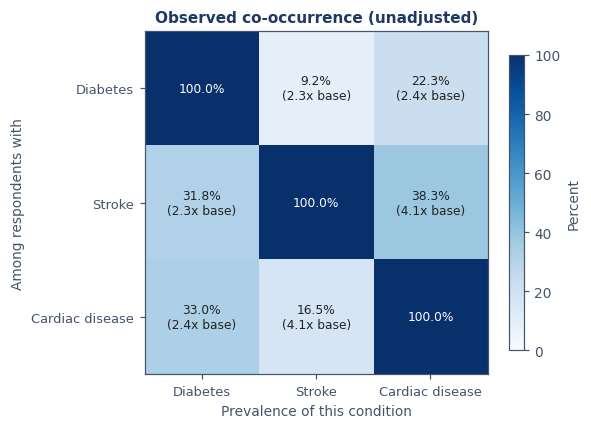

In [13]:
names = list(OUTCOMES)
M = np.zeros((3, 3))
for i, a in enumerate(names):
    sub = brfss[brfss[OUTCOMES[a]] == 1]
    for j, b in enumerate(names):
        M[i, j] = 100 * sub[OUTCOMES[b]].mean()

fig, ax = plt.subplots(figsize=(5.4, 4.4))
im = ax.imshow(M, cmap="Blues", vmin=0, vmax=max(60, M.max()))
ax.set_xticks(range(3), names, fontsize=8.5)
ax.set_yticks(range(3), names, fontsize=8.5)
ax.set_xlabel("Prevalence of this condition")
ax.set_ylabel("Among respondents with")
ax.set_title("Observed co-occurrence (unadjusted)")
for i in range(3):
    for j in range(3):
        txt = f"{M[i, j]:.1f}%"
        if i != j:
            txt += f"\n({M[i, j] / base[names[j]]:.1f}x base)"
        ax.text(j, i, txt, ha="center", va="center", fontsize=8,
                color="white" if M[i, j] > M.max() * 0.55 else "#222222")
fig.colorbar(im, ax=ax, shrink=0.75, label="Percent")
plt.tight_layout(); plt.show()

All three pairs co-occur substantially more often than independence would predict. The two
cardiovascular outcomes are linked to each other at **4.1× base rate**, roughly twice the strength
of either one's association with diabetes at 2.3× and 2.4×.

**The three conditions do not cluster uniformly.** This suggests any shared predictor core may
prove cardiovascular in character rather than common to all three — a testable expectation for the
modeling stage.

Note that lift is symmetric by construction: `P(A∩B) / (P(A)·P(B))` is the same in both directions,
so lift alone cannot identify which diagnosis is the better screening trigger. The directional
conditional probabilities in the cells are required for that.

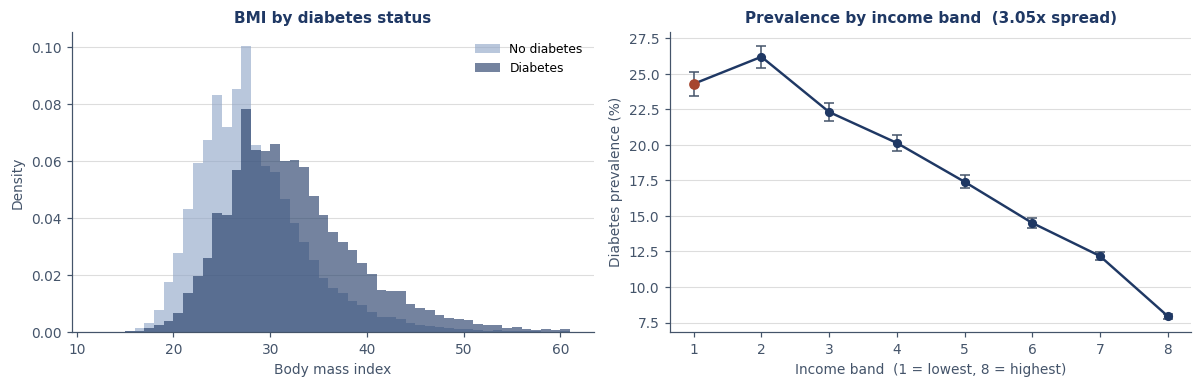

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.0, 3.6))

# density, not counts: the groups are 86% / 14% and raw counts would render the
# diabetes distribution as an invisible sliver. Shared bins are mandatory.
bins = np.arange(12, 62, 1)
for val, lab, col in [(0, "No diabetes", MID), (1, "Diabetes", NAVY)]:
    ax1.hist(brfss.loc[brfss["Diabetes_binary"] == val, "BMI"], bins=bins,
             density=True, alpha=0.62, label=lab, color=col, edgecolor="none")
ax1.set_xlabel("Body mass index"); ax1.set_ylabel("Density")
ax1.set_title("BMI by diabetes status")
ax1.legend(frameon=False, fontsize=8); clean(ax1)

g = brfss.groupby("Income")["Diabetes_binary"].agg(["mean", "size"])
p, n_ = g["mean"].to_numpy(), g["size"].to_numpy()
se = 100 * np.sqrt(p * (1 - p) / n_)
ax2.errorbar(g.index, 100 * p, yerr=1.96 * se, marker="o", color=NAVY,
             lw=1.6, ms=5, capsize=3, ecolor=SLATE, elinewidth=1)
ax2.plot(g.index[0], 100 * p[0], marker="o", ms=6, color=ACCENT, zorder=4)
ax2.set_xticks(g.index)
ax2.set_xlabel("Income band  (1 = lowest, 8 = highest)")
ax2.set_ylabel("Diabetes prevalence (%)")
ax2.set_title(f"Prevalence by income band  ({p[0]/p[-1]:.2f}x spread)")
clean(ax2)

plt.tight_layout(); plt.show()

In [15]:
# Cohen's d with a properly pooled standard deviation. At n = 253,680 a t-test
# returns a p-value carrying no information; the effect size is what matters.
def cohens_d(outcome_col):
    a = brfss.loc[brfss[outcome_col] == 0, "BMI"]
    b = brfss.loc[brfss[outcome_col] == 1, "BMI"]
    sd = np.sqrt(((len(a) - 1) * a.var(ddof=1) + (len(b) - 1) * b.var(ddof=1))
                 / (len(a) + len(b) - 2))
    return {"outcome": outcome_col, "mean_without": round(a.mean(), 2),
            "mean_with": round(b.mean(), 2), "cohens_d": round((b.mean() - a.mean()) / sd, 3)}

pd.DataFrame([cohens_d(c) for c in OUTCOMES.values()])

,outcome,mean_without,mean_with,cohens_d
0,Diabetes_binary,27.81,31.94,0.641
1,Stroke,28.35,29.03,0.102
2,HeartDiseaseorAttack,28.27,29.47,0.181


Mean BMI is 27.81 among respondents without diabetes and 31.94 among those with — a standardized
mean difference of **0.641**, with the two group means falling on opposite sides of the obesity
threshold. The same statistic for the cardiovascular outcomes yields 0.181 and 0.102, both below
the conventional threshold for a *small* effect.

BMI discriminates diabetes roughly **3.5× more strongly than cardiac disease and 6.3× more strongly
than stroke**. At these sample sizes the standard error on each estimate is about 0.006, so the
ordering is not attributable to sampling variation.

On the income gradient: prevalence declines from 26.19% in band 2 to 7.96% in band 8, a ratio of
**3.05**, monotonic across bands 2 through 8. That is consistent with a *graded* relationship
rather than a threshold effect, which bears on whether cutoff-based program eligibility would be
appropriate design.

The lowest band departs from the pattern at 24.29% (marked in red). With 9,811 respondents its
confidence interval does not overlap band 2, so the reversal is not sampling variation. Three
explanations warrant examination and are not mutually exclusive:

1. The outcome measures **diagnosed** diabetes, so reduced healthcare contact in the lowest income
   stratum may lower *detection* rather than disease.
2. Survey coverage of that stratum is incomplete, and the public extract omits corrective weights.
3. The income bands are unequal in width and may differ in demographic composition.

The access-to-care variables provide a direct means of examining the first.

---

## 7. Summary of Findings

| # | Finding | Evidence |
|---|---|---|
| 1 | Prior inpatient utilization is the dominant predictor | 7.25 pp binary contrast; 12.98 pp across deciles; VIF ≈ 1.0 |
| 2 | Encoding choice changes the apparent signal | Emergency visits: 0.00 pp by decile, 3.28 pp binary |
| 3 | Utilization variables are zero-inflated, not merely skewed | Excess kurtosis to 1,207.94; 87–93% zero |
| 4 | Two features are left-skewed | Lab procedures −0.22, diagnoses −0.73 |
| 5 | Outlier rules do not transfer across variable types | Tukey flags 3,851 records on a 0–6 range |
| 6 | No problematic collinearity | Maximum VIF 4.04 |
| 7 | The three survey conditions do not cluster uniformly | 4.1× stroke–cardiac vs 2.3–2.4× with diabetes |
| 8 | BMI discriminates diabetes far more strongly | d = 0.641 vs 0.181 and 0.102 |
| 9 | Strong income gradient with one anomalous band | 3.05× spread; band 1 departs, non-overlapping CI |

---

## 8. Implications for the Analysis

- Binary indicators are retained **alongside** raw counts and log transforms for the
  prior-utilization variables. Linear models use the binary form; tree models use raw counts, which
  they handle without transformation.
- All thirteen numeric predictors enter the multivariable specification. No feature is removed on
  collinearity grounds.
- Winsorization is specified **per variable** rather than applied uniformly.
- Precision-recall metrics are the headline for every classification outcome, given prevalences
  between 4.1% and 13.9%.
- Cross-validation must **group by patient identifier** — roughly 23% of patients contribute more
  than one encounter.
- Subgroup performance is reported for the demographic categories in section 4.2. Unadjusted rate
  differences are not treated as evidence of model bias in either direction.